In [5]:
import pandas as pd
import numpy as np

# ===========================
# 最简单的方案：直接使用现有数据
# ===========================

# 加载数据
race_data = pd.read_csv('data/f1_race_data_cleaned.csv')
teams_info = pd.read_csv('data/teams_info.csv')
driver_features = pd.read_csv('data/driver_features.csv')

# 创建映射
unique_drivers = race_data['Driver'].unique()
driver_to_idx = {driver: idx for idx, driver in enumerate(unique_drivers)}
team_tier_map = dict(zip(teams_info['Team'], teams_info['Tier']))

# 从driver_features创建映射
driver_recent5_map = dict(zip(driver_features['Driver'], driver_features['Recent5Avg']))
driver_dnf_map = dict(zip(driver_features['Driver'], driver_features['DNFRate']))

# ===========================
# 卡塔尔站数据
# ===========================

qatar_data = {
    'Driver': ['O PIASTRI', 'L NORRIS', 'M VERSTAPPEN', 'G RUSSELL', 'K ANTONELLI',
               'I HADJAR', 'C SAINZ', 'F ALONSO', 'P GASLY', 'C LECLERC',
               'N HULKENBERG', 'L LAWSON', 'O BEARMAN', 'G BORTOLETO', 'A ALBON',
               'Y TSUNODA', 'E OCON', 'L HAMILTON', 'L STROLL', 'F COLAPINTO'],
    
    'QualifyingPosition': list(range(1, 21)),
    'GridPosition': list(range(1, 21)),
    
    'Team': ['McLaren', 'McLaren', 'Red Bull Racing', 'Mercedes', 'Mercedes',
             'Racing Bulls', 'Williams', 'Aston Martin', 'Alpine', 'Ferrari',
             'Kick Sauber', 'Racing Bulls', 'Haas F1 Team', 'Kick Sauber', 'Williams',
             'Red Bull Racing', 'Haas F1 Team', 'Ferrari', 'Aston Martin', 'Alpine'],
    
    'TrackType': ['high_speed'] * 20,
    'GlobalRound': [1] * 20,
}

qatar_df = pd.DataFrame(qatar_data)

# ===========================
# 补齐特征
# ===========================

track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}

qatar_df['TrackTypeIdx'] = qatar_df['TrackType'].map(track_type_map)
qatar_df['TierCode'] = qatar_df['Team'].map(team_tier_map)
qatar_df['DriverIdx'] = qatar_df['Driver'].map(driver_to_idx)

# 直接从driver_features获取
qatar_df['Recent5Avg'] = qatar_df['Driver'].map(driver_recent5_map)
qatar_df['CumDNFRate'] = qatar_df['Driver'].map(driver_dnf_map)
qatar_df.to_csv('./data/qatar_ready.csv')

gamma_driver shape: (4, 4000, 22)
模型中的车手数: 22

预测结果（含众数）：

      Driver      Mean    Median      Mode
   O PIASTRI  4.043654  2.686229  1.057057
    L NORRIS  4.109801  2.800521  1.057057
M VERSTAPPEN  4.552880  3.469984  1.076076
   G RUSSELL  5.172376  4.317790  1.095095
 K ANTONELLI  5.986859  5.339518  1.114114
     C SAINZ  8.529977  8.331227  8.284284
   C LECLERC  9.615204  9.507177  8.987988
    I HADJAR 10.314962 10.370639 11.384384
    F ALONSO 10.966385 11.023689  9.976977
    L LAWSON 12.244885 12.377662 12.240240

✅ 完成


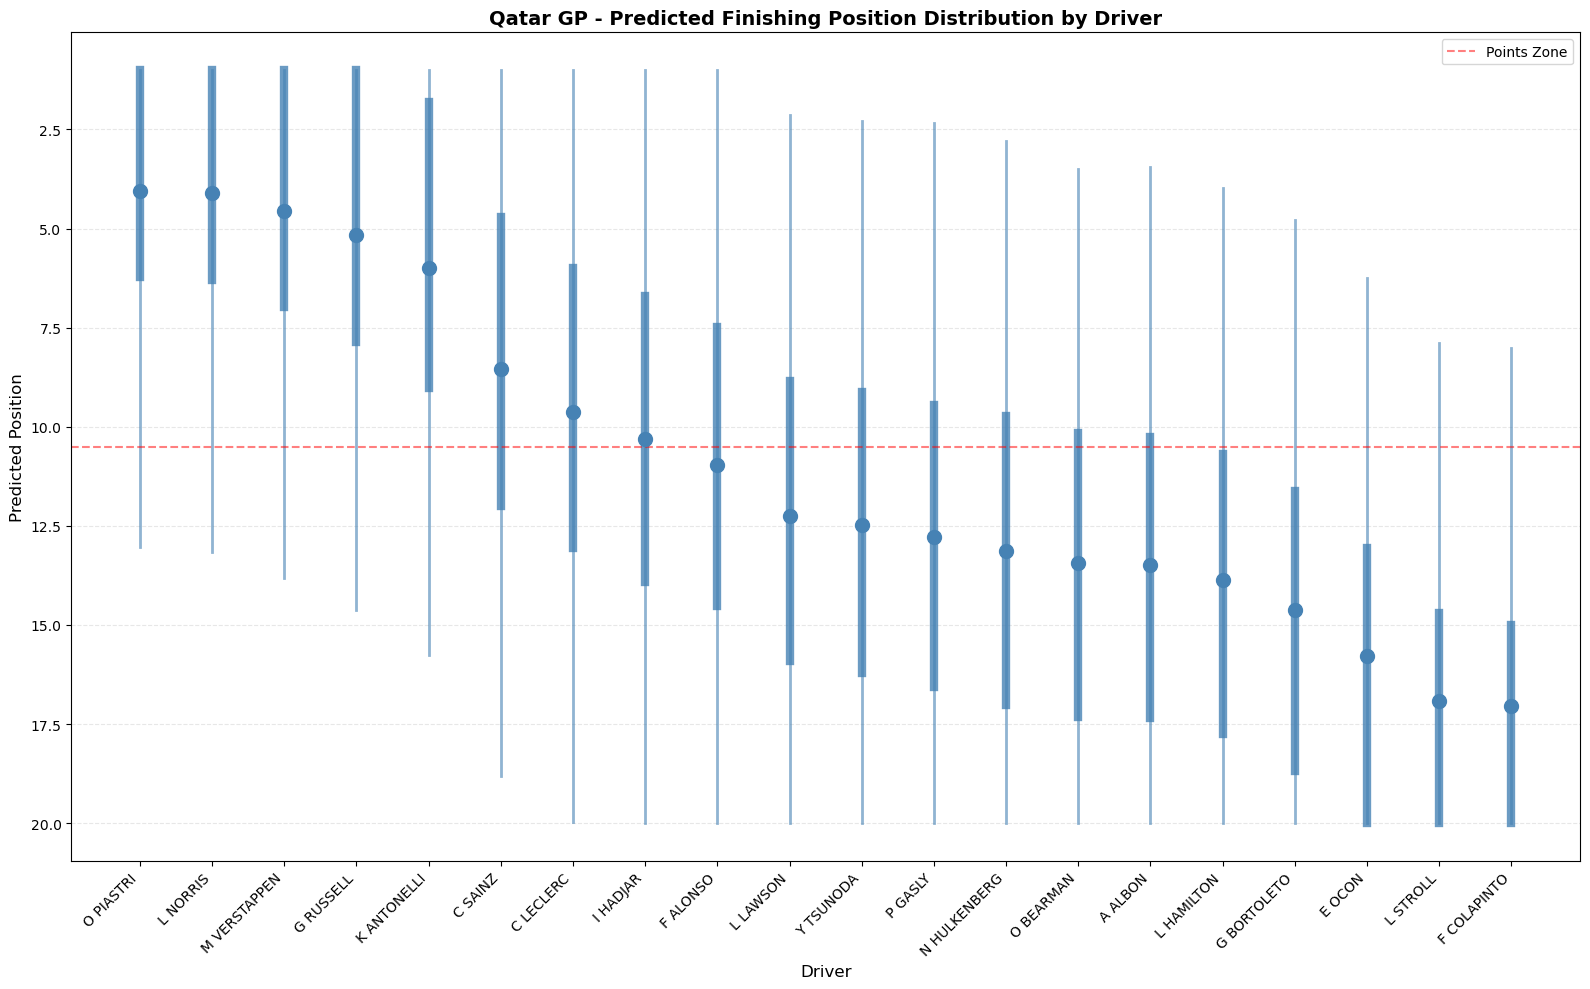

In [6]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

# 加载数据和模型
qatar_df = pd.read_csv('./data/qatar_ready.csv')
trace = az.from_netcdf('./model/f1_trace.nc')

print("gamma_driver shape:", trace.posterior['gamma_driver'].shape)
n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]
print(f"模型中的车手数: {n_drivers_in_model}")

# 提取后验参数
posterior = trace.posterior
alpha = posterior['alpha'].values.flatten()
beta_team = posterior['beta_team'].values.reshape(-1, 3)
gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
eta_grid = posterior['eta_grid'].values.flatten()
delta_track = posterior['delta_track'].values.reshape(-1, 3)
epsilon_trend = posterior['epsilon_trend'].values.flatten()
zeta_dnf = posterior['zeta_dnf'].values.flatten()
sigma_race = posterior['sigma_race'].values.flatten()

# 预测
results = []

for idx, row in qatar_df.iterrows():
    driver_idx = int(row['DriverIdx'])
    
    if driver_idx >= n_drivers_in_model:
        print(f"警告: {row['Driver']} 的 DriverIdx={driver_idx} 超出模型范围")
        continue
    
    mu = (
        alpha +
        beta_team[:, int(row['TierCode'])] +
        gamma_driver[:, driver_idx] +
        eta_grid * row['GridPosition'] +
        delta_track[:, int(row['TrackTypeIdx'])] +
        epsilon_trend * row['Recent5Avg'] +
        zeta_dnf * row['CumDNFRate']
    )
    
    positions = np.random.normal(mu, sigma_race)
    positions = np.clip(positions, 1, 20)
    
    # 计算众数（使用核密度估计）
    kde = stats.gaussian_kde(positions)
    x_range = np.linspace(1, 20, 1000)
    density = kde(x_range)
    mode = x_range[np.argmax(density)]
    
    results.append({
        'Driver': row['Driver'],
        'Mean': positions.mean(),
        'Median': np.median(positions),
        'Mode': mode,  # 众数
        'Q25': np.percentile(positions, 25),
        'Q75': np.percentile(positions, 75),
        'CI_2.5': np.percentile(positions, 2.5),
        'CI_97.5': np.percentile(positions, 97.5)
    })

results_df = pd.DataFrame(results).sort_values('Mean')
results_df.to_csv('./data/qatar_predict.csv', index=False)

print("\n预测结果（含众数）：\n")
print(results_df[['Driver', 'Mean', 'Median', 'Mode']].head(10).to_string(index=False))

# 绘图
fig, ax = plt.subplots(figsize=(16, 10))

drivers = results_df['Driver'].values
means = results_df['Mean'].values
q25 = results_df['Q25'].values
q75 = results_df['Q75'].values
ci_lower = results_df['CI_2.5'].values
ci_upper = results_df['CI_97.5'].values

x_pos = np.arange(len(drivers))

for i in range(len(drivers)):
    ax.plot([x_pos[i], x_pos[i]], [ci_lower[i], ci_upper[i]], 
            color='steelblue', linewidth=2, alpha=0.6)
    ax.plot([x_pos[i], x_pos[i]], [q25[i], q75[i]], 
            color='steelblue', linewidth=6, alpha=0.8)

ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(drivers, rotation=45, ha='right')
ax.set_xlabel('Driver', fontsize=12)
ax.set_ylabel('Predicted Position', fontsize=12)
ax.set_title('Qatar GP - Predicted Finishing Position Distribution by Driver', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=10.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Points Zone')
ax.legend()

plt.tight_layout()
plt.savefig('qatar_position_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ 完成")
plt.show()

In [7]:
import pandas as pd

# 完整实际结果
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)


# 从CSV读取预测结果（无排名约束版本）
predicted_df = pd.read_csv('./data/qatar_predict.csv')

# 按PredictedPosition排序生成排名
predicted_df = predicted_df.sort_values('Mode').reset_index(drop=True)
predicted_df['PredictedRank'] = range(1, len(predicted_df) + 1)

# 合并
comparison = actual_df.merge(predicted_df, on='Driver')
comparison['RankDiff'] = abs(comparison['ActualPosition'] - comparison['PredictedRank'])

print("=" * 80)
print("Qatar predict (predict once)")
print("=" * 80)

# 详细对比
print("\n完整排名对比：\n")
print(comparison[['ActualPosition', 'Driver', 'PredictedRank', 'RankDiff']].to_string(index=False))

# 总体指标
print("\n" + "=" * 80)
print("总体准确性指标")
print("=" * 80)
print(f"平均排名误差: {comparison['RankDiff'].mean():.2f} 位")
print(f"中位数误差: {comparison['RankDiff'].median():.1f} 位")
print(f"最大误差: {comparison['RankDiff'].max():.0f} 位")

# 冠军预测
winner_actual = actual_df[actual_df['ActualPosition'] == 1]['Driver'].values[0]
winner_predicted = predicted_df[predicted_df['PredictedRank'] == 1]['Driver'].values[0]
winner_correct = winner_actual == winner_predicted

print("\n" + "=" * 80)
print("分段准确性")
print("=" * 80)

# P1 准确性
print(f"\n🏆 冠军预测: {'✓ 正确' if winner_correct else '✗ 错误'}")
print(f"   预测: {winner_predicted}")
print(f"   实际: {winner_actual}")

# 前3准确性
top3_actual = set(actual_df[actual_df['ActualPosition'] <= 3]['Driver'])
top3_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 3]['Driver'])
top3_correct = top3_actual & top3_predicted

print(f"\n🥇 领奖台(前3)准确性: {len(top3_correct)}/3 正确 ({len(top3_correct)/3*100:.0f}%)")
print(f"   预测: {sorted(top3_predicted)}")
print(f"   实际: {sorted(top3_actual)}")
print(f"   命中: {sorted(top3_correct)}")
print(f"   遗漏: {sorted(top3_actual - top3_predicted)}")

# 前5准确性
top5_actual = set(actual_df[actual_df['ActualPosition'] <= 5]['Driver'])
top5_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 5]['Driver'])
top5_correct = top5_actual & top5_predicted

print(f"\n🏁 前5准确性: {len(top5_correct)}/5 正确 ({len(top5_correct)/5*100:.0f}%)")
print(f"   预测: {sorted(top5_predicted)}")
print(f"   实际: {sorted(top5_actual)}")
print(f"   命中: {sorted(top5_correct)}")
print(f"   遗漏: {sorted(top5_actual - top5_predicted)}")

# 前10(积分区)准确性
top10_actual = set(actual_df[actual_df['ActualPosition'] <= 10]['Driver'])
top10_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 10]['Driver'])
top10_correct = top10_actual & top10_predicted

print(f"\n📊 积分区(前10)准确性: {len(top10_correct)}/10 正确 ({len(top10_correct)/10*100:.0f}%)")
print(f"   命中: {len(top10_correct)} 位车手")
print(f"   遗漏: {sorted(top10_actual - top10_predicted)}")

# 最大意外
print("\n" + "=" * 80)
print("预测偏差最大的车手")
print("=" * 80)
biggest_errors = comparison.nlargest(5, 'RankDiff')
for idx, row in biggest_errors.iterrows():
    direction = "表现优于预期" if row['ActualPosition'] < row['PredictedRank'] else "表现不及预期"
    print(f"{row['Driver']:20s} 实际P{row['ActualPosition']:2.0f} vs 预测P{row['PredictedRank']:2.0f} "
          f"(误差{row['RankDiff']:.0f}位) - {direction}")

print("\n" + "=" * 80)

Qatar predict (predict once)

完整排名对比：

 ActualPosition       Driver  PredictedRank  RankDiff
              1 M VERSTAPPEN              3         2
              2    O PIASTRI              1         1
              3      C SAINZ              6         3
              4     L NORRIS              2         2
              5  K ANTONELLI              5         0
              6    G RUSSELL              4         2
              7     F ALONSO              8         1
              8    C LECLERC              7         1
              9     L LAWSON             10         1
             10    Y TSUNODA             11         1
             11      A ALBON             15         4
             12   L HAMILTON             16         4
             13  G BORTOLETO             17         4
             14  F COLAPINTO             20         6
             15       E OCON             18         3
             16      P GASLY             12         4
             17     L STROLL             19

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

qatar_df = pd.read_csv('data/qatar_ready.csv')
trace = az.from_netcdf('model/f1_trace.nc')

# 提取后验参数
posterior = trace.posterior
n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]

alpha = posterior['alpha'].values.flatten()
beta_team = posterior['beta_team'].values.reshape(-1, 3)
gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
eta_grid = posterior['eta_grid'].values.flatten()
delta_track = posterior['delta_track'].values.reshape(-1, 3)
epsilon_trend = posterior['epsilon_trend'].values.flatten()
zeta_dnf = posterior['zeta_dnf'].values.flatten()
sigma_race = posterior['sigma_race'].values.flatten()

n_samples = len(alpha)
n_simulations = 5000_00

print(f"开始蒙特卡洛模拟 ({n_simulations:,} 次)...")

# ===========================
# 蒙特卡洛模拟：生成完整排名
# ===========================

position_counts = np.zeros((len(qatar_df), 20))

for sim in range(n_simulations):
    if sim % 10000 == 0:
        print(f"  进度: {sim/n_simulations*100:.1f}%", end='\r')
    
    sample_idx = np.random.randint(0, n_samples)
    
    predicted_positions = []
    for idx, row in qatar_df.iterrows():
        mu = (
            alpha[sample_idx] +
            beta_team[sample_idx, int(row['TierCode'])] +
            gamma_driver[sample_idx, int(row['DriverIdx'])] +
            eta_grid[sample_idx] * row['GridPosition'] +
            delta_track[sample_idx, int(row['TrackTypeIdx'])] +
            epsilon_trend[sample_idx] * row['Recent5Avg'] +
            zeta_dnf[sample_idx] * row['CumDNFRate']
        )
        
        pos = np.random.normal(mu, sigma_race[sample_idx])
        predicted_positions.append(pos)
    
    # 关键：使用argsort得到排名，确保1-20不重复
    ranks = np.argsort(predicted_positions) + 1
    
    for driver_idx, rank in enumerate(ranks):
        if 1 <= rank <= 20:
            position_counts[driver_idx, rank - 1] += 1

print(f"  进度: 100.0% - 完成!")

position_probs = position_counts / n_simulations

# ===========================
# 计算统计量
# ===========================

results = []
for idx, row in qatar_df.iterrows():
    probs = position_probs[idx]
    
    # 期望值（Mean）
    expected_pos = np.sum([(i+1) * probs[i] for i in range(20)])
    
    # 中位数（Median）
    cumsum = np.cumsum(probs)
    median_pos = np.searchsorted(cumsum, 0.5) + 1
    
    # 众数（Mode）- 概率最高的排名
    mode_pos = np.argmax(probs) + 1
    
    # 分位数
    q25 = np.searchsorted(cumsum, 0.25) + 1
    q75 = np.searchsorted(cumsum, 0.75) + 1
    ci_lower = np.searchsorted(cumsum, 0.025) + 1
    ci_upper = np.searchsorted(cumsum, 0.975) + 1
    
    # 🔥 新增：Top3/5/10概率和熵
    p_top3 = probs[:3].sum()
    p_top5 = probs[:5].sum()
    p_top10 = probs[:10].sum()
    entropy = -np.sum(probs[probs > 0] * np.log(probs[probs > 0] + 1e-10))
    
    results.append({
        'Driver': row['Driver'],
        'Mean': expected_pos,           # 期望排名（可以是小数）
        'Median': median_pos,            # 中位数排名
        'Mode': mode_pos,                # 众数排名（最可能）
        'P_Win': probs[0],               # 夺冠概率
        'P_Top3': p_top3,                # 🔥 新增：前3概率
        'P_Top5': p_top5,                # 🔥 新增：前5概率
        'P_Top10': p_top10,              # 🔥 新增：前10概率
        'P_Podium': probs[:3].sum(),     # 领奖台概率（同P_Top3）
        'P_Points': probs[:10].sum(),    # 得分概率（同P_Top10）
        'Q25': q25,
        'Q75': q75,
        'CI_2.5': ci_lower,
        'CI_97.5': ci_upper,
        'Entropy': entropy               # 🔥 新增：不确定性
    })

# ===========================
# 🔥 关键修复：排序并生成唯一的 PredictedRank
# ===========================

results_df = pd.DataFrame(results)

# 按照你的排序规则排序
results_df = results_df.sort_values(
    by=['Mode', 'Mean', 'P_Win', 'Q25', 'CI_2.5'],
    ascending=[True, True, False, True, True]
)

# 🎯 关键：根据排序后的顺序，累加生成唯一的排名（1-20）
results_df.insert(0, 'PredictedRank', range(1, len(results_df) + 1))

# 重新排列列
results_df = results_df[[
    'PredictedRank',     # 👈 综合预测排名（1-20，唯一）
    'Driver', 
    'Mean',              # 期望排名（连续值）
    'Median',            # 中位数
    'Mode',              # 众数（可能重复）
    'P_Win',             # 夺冠概率
    'P_Top3',            # 🔥 前3概率
    'P_Top5',            # 🔥 前5概率
    'P_Top10',           # 🔥 前10概率
    'P_Podium',          # 领奖台概率
    'P_Points',          # 得分概率
    'Q25',
    'Q75',
    'CI_2.5',
    'CI_97.5',
    'Entropy'            # 🔥 不确定性
]]

# ===========================
# 输出结果
# ===========================

print("\n" + "=" * 100)
print("卡塔尔站预测（考虑排名约束）")
print("=" * 100)
print("\n排序规则: Mode → Mean → P_Win(降序) → Q25 → CI_2.5")
print("PredictedRank = 根据排序规则累加得到的唯一排名（1-20）\n")

print(results_df[['PredictedRank', 'Driver', 'Mean', 'Mode', 
                  'P_Win', 'P_Top3', 'P_Top10']].to_string(index=False))

# 保存
results_df.to_csv('./data/qatar_predict_menka.csv', index=False)

print("\n" + "=" * 100)
print("✅ 预测结果已保存到 qatar_predict_menka.csv")
print("   'PredictedRank' 列 = 综合预测的唯一最终排名（1-20）")
print("=" * 100)

# ===========================
# 验证：确保没有重复排名
# ===========================

print("\n" + "=" * 100)
print("验证结果")
print("=" * 100)

# 检查 PredictedRank 是否唯一
assert results_df['PredictedRank'].nunique() == 20, "❌ PredictedRank 有重复！"
assert set(results_df['PredictedRank']) == set(range(1, 21)), "❌ PredictedRank 不完整！"

print("✅ PredictedRank: 1-20，无重复，无遗漏")

# 检查 Mode 可能的重复情况
mode_duplicates = results_df['Mode'].value_counts()
if (mode_duplicates > 1).any():
    print(f"\n⚠️  Mode 有重复值（这是正常的）:")
    print(mode_duplicates[mode_duplicates > 1])
    print("   → 这就是为什么需要用 Mean、P_Win 等作为 tie-breaker")

# 展示前5名的详细排序逻辑
print("\n前5名的排序依据:")
top5 = results_df.head(5)
for _, row in top5.iterrows():
    print(f"P{row['PredictedRank']:.0f} {row['Driver']:18s}  "
          f"Mode={row['Mode']:2.0f}  Mean={row['Mean']:5.2f}  "
          f"P_Win={row['P_Win']:5.1%}  Q25={row['Q25']:2.0f}  "
          f"Entropy={row['Entropy']:.3f}")

print("\n" + "=" * 100)

开始蒙特卡洛模拟 (500,000 次)...
  进度: 100.0% - 完成!

卡塔尔站预测（考虑排名约束）

排序规则: Mode → Mean → P_Win(降序) → Q25 → CI_2.5
PredictedRank = 根据排序规则累加得到的唯一排名（1-20）

 PredictedRank       Driver      Mean  Mode    P_Win   P_Top3  P_Top10
             1 M VERSTAPPEN  5.191976     1 0.143156 0.426758 0.891588
             2    O PIASTRI  3.439884     2 0.224764 0.635334 0.971144
             3     L NORRIS  4.295970     2 0.178930 0.522816 0.936618
             4    G RUSSELL  6.119224     4 0.112506 0.340820 0.839080
             5  K ANTONELLI  7.075082     5 0.087008 0.266132 0.778162
             6     I HADJAR  7.992608     5 0.065574 0.203940 0.715478
             7      C SAINZ  8.833070     7 0.049478 0.155622 0.652760
             8    C LECLERC 10.842376     8 0.020996 0.067962 0.485872
             9 N HULKENBERG 11.382498     8 0.015690 0.050540 0.438684
            10     F ALONSO  9.584428    10 0.037460 0.118876 0.592342
            11      P GASLY 10.251140    10 0.027948 0.088760 0.537238
    


✅ 完成


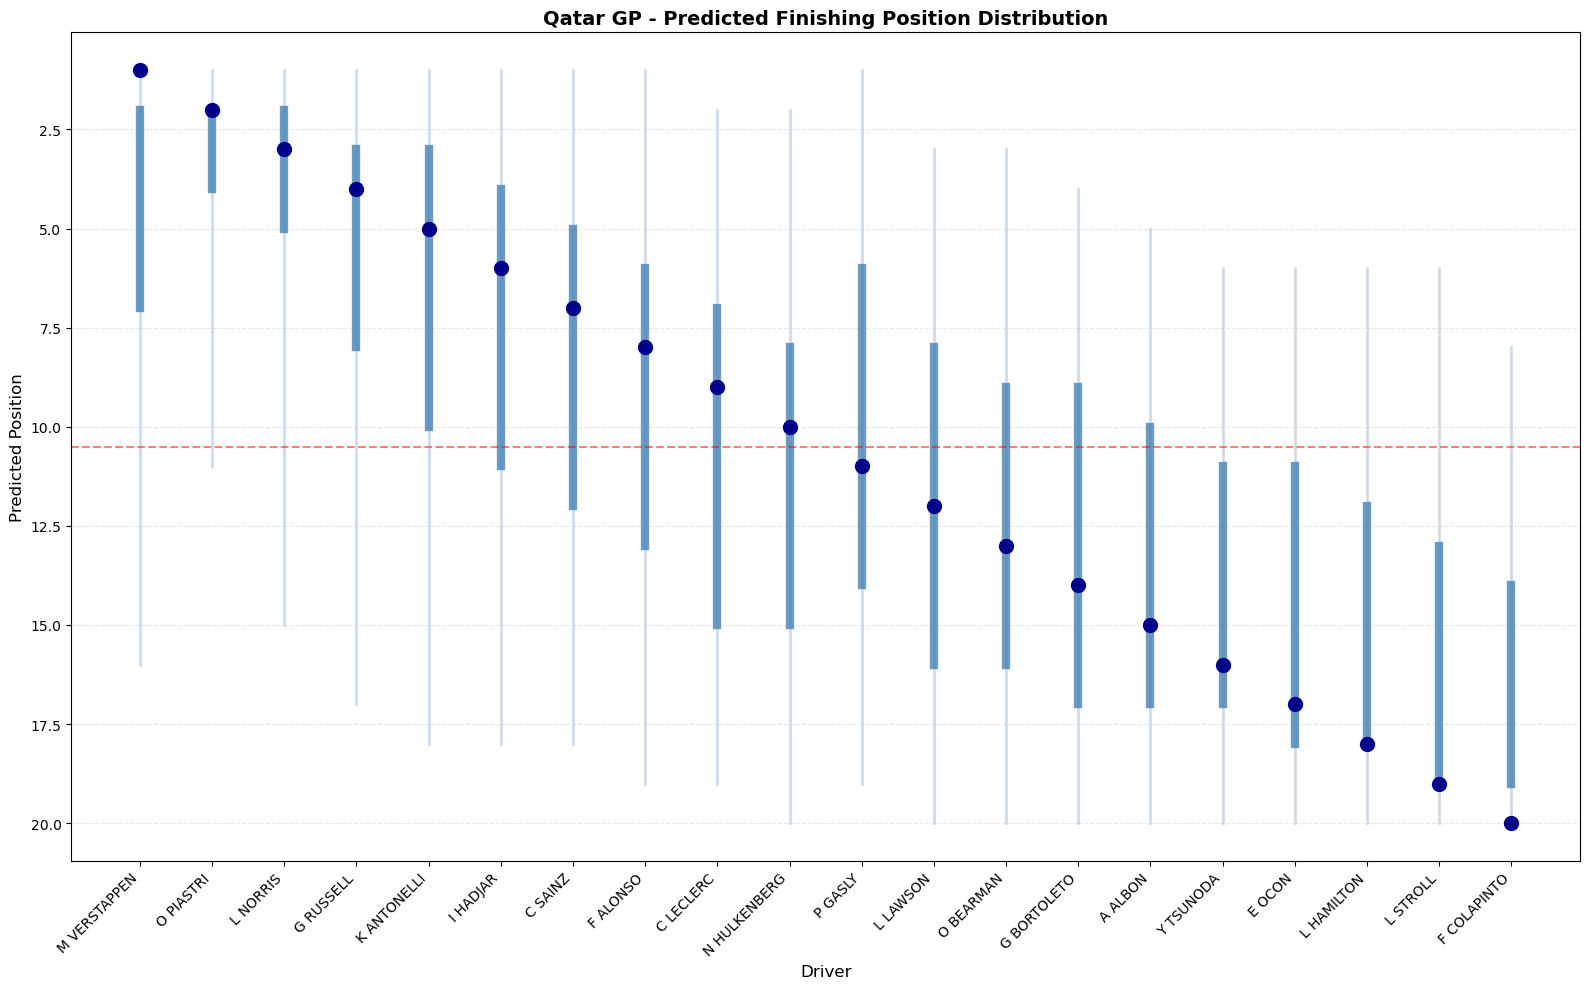

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# 绘图
# ===========================

results_df = pd.read_csv('./data/qatar_predict_menka.csv')

fig, ax = plt.subplots(figsize=(16, 10))

drivers = results_df['Driver'].values
predicted_rank = results_df['PredictedRank'].values
q25 = results_df['Q25'].values
q75 = results_df['Q75'].values
ci_lower = results_df['CI_2.5'].values
ci_upper = results_df['CI_97.5'].values

x_pos = np.arange(len(drivers))

# 绘制置信区间和分位数
for i in range(len(drivers)):
    ax.plot([x_pos[i], x_pos[i]], [ci_lower[i], ci_upper[i]], 
            color='lightsteelblue', linewidth=2, alpha=0.6)
    ax.plot([x_pos[i], x_pos[i]], [q25[i], q75[i]], 
            color='steelblue', linewidth=6, alpha=0.8)

# 绘制预测排名点
ax.scatter(x_pos, predicted_rank, color='darkblue', s=100, zorder=3)

# 设置坐标轴
ax.set_xticks(x_pos)
ax.set_xticklabels(drivers, rotation=45, ha='right')
ax.set_xlabel('Driver', fontsize=12)
ax.set_ylabel('Predicted Position', fontsize=12)
ax.set_title('Qatar GP - Predicted Finishing Position Distribution', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=10.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.savefig('qatar_position_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ 完成")
plt.show()

In [10]:
import pandas as pd

# 实际结果
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)

# 从CSV读取预测结果
predicted_df = pd.read_csv('./data/qatar_predict_menka.csv')

# 合并（直接使用PredictedRank）
comparison = actual_df.merge(predicted_df[['Driver', 'PredictedRank']], on='Driver')
comparison['RankDiff'] = abs(comparison['ActualPosition'] - comparison['PredictedRank'])

print("=" * 80)
print("卡塔尔站预测准确性分析（蒙特卡洛排名约束） function1")
print("=" * 80)

print("\n完整排名对比：\n")
print(comparison[['ActualPosition', 'Driver', 'PredictedRank', 'RankDiff']].to_string(index=False))

print("\n" + "=" * 80)
print("总体准确性指标")
print("=" * 80)
print(f"平均排名误差: {comparison['RankDiff'].mean():.2f} 位")
print(f"中位数误差: {comparison['RankDiff'].median():.1f} 位")
print(f"最大误差: {comparison['RankDiff'].max():.0f} 位")

winner_actual = actual_df[actual_df['ActualPosition'] == 1]['Driver'].values[0]
winner_predicted = predicted_df[predicted_df['PredictedRank'] == 1]['Driver'].values[0]
winner_correct = winner_actual == winner_predicted

print("\n" + "=" * 80)
print("分段准确性")
print("=" * 80)

print(f"\n🏆 冠军预测: {'✓ 正确' if winner_correct else '✗ 错误'}")
print(f"   预测: {winner_predicted}")
print(f"   实际: {winner_actual}")

top3_actual = set(actual_df[actual_df['ActualPosition'] <= 3]['Driver'])
top3_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 3]['Driver'])
top3_correct = top3_actual & top3_predicted

print(f"\n🥇 领奖台(前3)准确性: {len(top3_correct)}/3 正确 ({len(top3_correct)/3*100:.0f}%)")
print(f"   预测: {sorted(top3_predicted)}")
print(f"   实际: {sorted(top3_actual)}")
print(f"   命中: {sorted(top3_correct)}")
print(f"   遗漏: {sorted(top3_actual - top3_predicted)}")

top5_actual = set(actual_df[actual_df['ActualPosition'] <= 5]['Driver'])
top5_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 5]['Driver'])
top5_correct = top5_actual & top5_predicted

print(f"\n🏁 前5准确性: {len(top5_correct)}/5 正确 ({len(top5_correct)/5*100:.0f}%)")
print(f"   预测: {sorted(top5_predicted)}")
print(f"   实际: {sorted(top5_actual)}")
print(f"   命中: {sorted(top5_correct)}")
print(f"   遗漏: {sorted(top5_actual - top5_predicted)}")

top10_actual = set(actual_df[actual_df['ActualPosition'] <= 10]['Driver'])
top10_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 10]['Driver'])
top10_correct = top10_actual & top10_predicted

print(f"\n📊 积分区(前10)准确性: {len(top10_correct)}/10 正确 ({len(top10_correct)/10*100:.0f}%)")
print(f"   命中: {len(top10_correct)} 位车手")
print(f"   遗漏: {sorted(top10_actual - top10_predicted)}")

print("\n" + "=" * 80)
print("预测偏差最大的车手")
print("=" * 80)
biggest_errors = comparison.nlargest(5, 'RankDiff')
for idx, row in biggest_errors.iterrows():
    direction = "表现优于预期" if row['ActualPosition'] < row['PredictedRank'] else "表现不及预期"
    print(f"{row['Driver']:20s} 实际P{row['ActualPosition']:2.0f} vs 预测P{row['PredictedRank']:2.0f} "
          f"(误差{row['RankDiff']:.0f}位) - {direction}")

print("\n" + "=" * 80)

卡塔尔站预测准确性分析（蒙特卡洛排名约束） function1

完整排名对比：

 ActualPosition       Driver  PredictedRank  RankDiff
              1 M VERSTAPPEN              1         0
              2    O PIASTRI              2         0
              3      C SAINZ              7         4
              4     L NORRIS              3         1
              5  K ANTONELLI              5         0
              6    G RUSSELL              4         2
              7     F ALONSO              8         1
              8    C LECLERC              9         1
              9     L LAWSON             12         3
             10    Y TSUNODA             16         6
             11      A ALBON             15         4
             12   L HAMILTON             18         6
             13  G BORTOLETO             14         1
             14  F COLAPINTO             20         6
             15       E OCON             17         2
             16      P GASLY             11         5
             17     L STROLL            

In [11]:
import pandas as pd
import numpy as np
import arviz as az

qatar_df = pd.read_csv('data/qatar_ready.csv')
trace = az.from_netcdf('model/f1_trace.nc')

# 提取后验参数
posterior = trace.posterior
n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]

alpha = posterior['alpha'].values.flatten()
beta_team = posterior['beta_team'].values.reshape(-1, 3)
gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
eta_grid = posterior['eta_grid'].values.flatten()
delta_track = posterior['delta_track'].values.reshape(-1, 3)
epsilon_trend = posterior['epsilon_trend'].values.flatten()
zeta_dnf = posterior['zeta_dnf'].values.flatten()
sigma_race = posterior['sigma_race'].values.flatten()

n_samples = len(alpha)
n_simulations = 500000

print(f"开始蒙特卡洛模拟 ({n_simulations:,} 次)...")

print(f"开始蒙特卡洛模拟 ({n_simulations:,} 次)...")

position_counts = np.zeros((len(qatar_df), 20))

for sim in range(n_simulations):
    if sim % 10000 == 0:
        print(f"  进度: {sim/n_simulations*100:.1f}%", end='\r')
    
    sample_idx = np.random.randint(0, n_samples)
    
    predicted_positions = []
    for idx, row in qatar_df.iterrows():
        mu = (
            alpha[sample_idx] +
            beta_team[sample_idx, int(row['TierCode'])] +
            gamma_driver[sample_idx, int(row['DriverIdx'])] +
            eta_grid[sample_idx] * row['GridPosition'] +
            delta_track[sample_idx, int(row['TrackTypeIdx'])] +
            epsilon_trend[sample_idx] * row['Recent5Avg'] +
            zeta_dnf[sample_idx] * row['CumDNFRate']
        )
        pos = np.random.normal(mu, sigma_race[sample_idx])
        predicted_positions.append(pos)
    
    ranks = np.argsort(predicted_positions)
    
    for driver_idx, rank in enumerate(ranks):
        if rank < 20:
            position_counts[driver_idx, rank] += 1

print(f"  进度: 100.0% - 完成!")

position_probs = position_counts / n_simulations

# ===========================
# 计算统计量
# ===========================

results = []
for idx, row in qatar_df.iterrows():
    probs = position_probs[idx]
    
    mode = np.argmax(probs) + 1
    mode_prob = probs[mode - 1]  # Mode的概率值
    mean = np.sum([(i+1) * probs[i] for i in range(20)])
    
    cumsum = np.cumsum(probs)
    median = np.searchsorted(cumsum, 0.5) + 1
    q25 = np.searchsorted(cumsum, 0.25) + 1
    q75 = np.searchsorted(cumsum, 0.75) + 1
    ci_lower = np.searchsorted(cumsum, 0.025) + 1
    ci_upper = np.searchsorted(cumsum, 0.975) + 1
    
    p_win = probs[0]
    p_top10 = probs[:10].sum()
    
    # 🔥 关键：计算加权Mode（惩罚不稳定的车手）
    # 如果Mode的概率很低，说明预测很分散，应该惩罚
    if mode_prob < 0.15:  # Mode概率<15%，说明很不稳定
        adjusted_mode = mode + (mean - mode) * 0.5  # 向Mean靠拢
    else:
        adjusted_mode = mode
    
    results.append({
        'Driver': row['Driver'],
        'Mode': mode,
        'ModeProb': mode_prob,
        'AdjustedMode': adjusted_mode,
        'Mean': mean,
        'Median': median,
        'Q25': q25,
        'Q75': q75,
        'CI_2.5': ci_lower,
        'CI_97.5': ci_upper,
        'P_Win': p_win,
        'P_Top10': p_top10,
    })

results_df = pd.DataFrame(results)

# ===========================
# 🎯 使用AdjustedMode排序（Function1的改进版）
# ===========================

results_df = results_df.sort_values(
    by=['AdjustedMode', 'Mean', 'P_Win', 'Q25', 'CI_2.5'],
    ascending=[True, True, False, True, True]
).reset_index(drop=True)

results_df.insert(0, 'PredictedRank', range(1, len(results_df) + 1))

# ===========================
# 输出
# ===========================

print("\n" + "=" * 100)
print("卡塔尔站预测（Function1改进版 - 加权Mode）")
print("=" * 100)
print("\n排序规则: AdjustedMode → Mean → P_Win(降序) → Q25 → CI_2.5")
print("AdjustedMode = Mode (如果ModeProb>15%) 或 Mode向Mean调整\n")

print(results_df[[
    'PredictedRank', 'Driver', 'Mode', 'ModeProb', 'AdjustedMode',
    'Mean', 'P_Win', 'P_Top10'
]].to_string(index=False))

results_df.to_csv('./data/qatar_final_menka.csv', index=False)

print("\n" + "=" * 100)
print("✅ 最终预测已保存")
print("=" * 100)

# ===========================
# 分析哪些车手被调整了
# ===========================

print("\n" + "=" * 100)
print("调整分析")
print("=" * 100)

adjusted = results_df[results_df['ModeProb'] < 0.15].copy()
if len(adjusted) > 0:
    print("\n⚠️  Mode不稳定的车手（ModeProb < 15%）:")
    for _, row in adjusted.iterrows():
        change = row['AdjustedMode'] - row['Mode']
        print(f"  {row['Driver']:18s}  "
              f"Mode={row['Mode']:2.0f} (概率{row['ModeProb']:.1%})  "
              f"→ AdjustedMode={row['AdjustedMode']:5.2f}  "
              f"(调整{change:+.2f}位)")

print("\n" + "=" * 100)

开始蒙特卡洛模拟 (500,000 次)...
开始蒙特卡洛模拟 (500,000 次)...
  进度: 100.0% - 完成!

卡塔尔站预测（Function1改进版 - 加权Mode）

排序规则: AdjustedMode → Mean → P_Win(降序) → Q25 → CI_2.5
AdjustedMode = Mode (如果ModeProb>15%) 或 Mode向Mean调整

 PredictedRank       Driver  Mode  ModeProb  AdjustedMode      Mean    P_Win  P_Top10
             1    O PIASTRI     2  0.228810      2.000000  3.430678 0.225980 0.971362
             2     L NORRIS     2  0.178854      2.000000  4.307442 0.178848 0.936056
             3 M VERSTAPPEN     1  0.142728      3.099228  5.198456 0.142728 0.891234
             4    G RUSSELL     4  0.118548      5.057125  6.114250 0.112982 0.839248
             5  K ANTONELLI     5  0.103530      6.038073  7.076146 0.086812 0.778880
             6     I HADJAR     5  0.088840      6.494691  7.989382 0.065164 0.715536
             7      C SAINZ     7  0.083866      7.913530  8.827060 0.049592 0.652118
             8     F ALONSO     7  0.078622      8.287970  9.575940 0.036996 0.593234
             9    C LE

In [12]:
import pandas as pd

# 实际结果
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)

# 从CSV读取预测结果
predicted_df = pd.read_csv('./data/qatar_final_menka.csv')

# 合并（直接使用PredictedRank）
comparison = actual_df.merge(predicted_df[['Driver', 'PredictedRank']], on='Driver')
comparison['RankDiff'] = abs(comparison['ActualPosition'] - comparison['PredictedRank'])

print("=" * 80)
print("卡塔尔站预测准确性分析（蒙特卡洛排名约束）function2")
print("=" * 80)

print("\n完整排名对比：\n")
print(comparison[['ActualPosition', 'Driver', 'PredictedRank', 'RankDiff']].to_string(index=False))

print("\n" + "=" * 80)
print("总体准确性指标")
print("=" * 80)
print(f"平均排名误差: {comparison['RankDiff'].mean():.2f} 位")
print(f"中位数误差: {comparison['RankDiff'].median():.1f} 位")
print(f"最大误差: {comparison['RankDiff'].max():.0f} 位")

winner_actual = actual_df[actual_df['ActualPosition'] == 1]['Driver'].values[0]
winner_predicted = predicted_df[predicted_df['PredictedRank'] == 1]['Driver'].values[0]
winner_correct = winner_actual == winner_predicted

print("\n" + "=" * 80)
print("分段准确性")
print("=" * 80)

print(f"\n🏆 冠军预测: {'✓ 正确' if winner_correct else '✗ 错误'}")
print(f"   预测: {winner_predicted}")
print(f"   实际: {winner_actual}")

top3_actual = set(actual_df[actual_df['ActualPosition'] <= 3]['Driver'])
top3_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 3]['Driver'])
top3_correct = top3_actual & top3_predicted

print(f"\n🥇 领奖台(前3)准确性: {len(top3_correct)}/3 正确 ({len(top3_correct)/3*100:.0f}%)")
print(f"   预测: {sorted(top3_predicted)}")
print(f"   实际: {sorted(top3_actual)}")
print(f"   命中: {sorted(top3_correct)}")
print(f"   遗漏: {sorted(top3_actual - top3_predicted)}")

top5_actual = set(actual_df[actual_df['ActualPosition'] <= 5]['Driver'])
top5_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 5]['Driver'])
top5_correct = top5_actual & top5_predicted

print(f"\n🏁 前5准确性: {len(top5_correct)}/5 正确 ({len(top5_correct)/5*100:.0f}%)")
print(f"   预测: {sorted(top5_predicted)}")
print(f"   实际: {sorted(top5_actual)}")
print(f"   命中: {sorted(top5_correct)}")
print(f"   遗漏: {sorted(top5_actual - top5_predicted)}")

top10_actual = set(actual_df[actual_df['ActualPosition'] <= 10]['Driver'])
top10_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 10]['Driver'])
top10_correct = top10_actual & top10_predicted

print(f"\n📊 积分区(前10)准确性: {len(top10_correct)}/10 正确 ({len(top10_correct)/10*100:.0f}%)")
print(f"   命中: {len(top10_correct)} 位车手")
print(f"   遗漏: {sorted(top10_actual - top10_predicted)}")

print("\n" + "=" * 80)
print("预测偏差最大的车手")
print("=" * 80)
biggest_errors = comparison.nlargest(5, 'RankDiff')
for idx, row in biggest_errors.iterrows():
    direction = "表现优于预期" if row['ActualPosition'] < row['PredictedRank'] else "表现不及预期"
    print(f"{row['Driver']:20s} 实际P{row['ActualPosition']:2.0f} vs 预测P{row['PredictedRank']:2.0f} "
          f"(误差{row['RankDiff']:.0f}位) - {direction}")

print("\n" + "=" * 80)

卡塔尔站预测准确性分析（蒙特卡洛排名约束）function2

完整排名对比：

 ActualPosition       Driver  PredictedRank  RankDiff
              1 M VERSTAPPEN              3         2
              2    O PIASTRI              1         1
              3      C SAINZ              7         4
              4     L NORRIS              2         2
              5  K ANTONELLI              5         0
              6    G RUSSELL              4         2
              7     F ALONSO              8         1
              8    C LECLERC              9         1
              9     L LAWSON             12         3
             10    Y TSUNODA             16         6
             11      A ALBON             14         3
             12   L HAMILTON             18         6
             13  G BORTOLETO             13         0
             14  F COLAPINTO             20         6
             15       E OCON             17         2
             16      P GASLY             11         5
             17     L STROLL             

alpha*Mode + beta*Mean + theta*Pro_win 

def simular_game3:
    

     //game1
     //game2

     // judgement 

aplha,beta,gamma = simular_game3()

Rank = 0.4*Mode.......